In [1]:
!pip install gensim
!pip install pyLDAvis

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 96.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 101.0 MB/s eta 0:00:00


In [2]:
import os
import random

# Fijamos semillas y hash para maximizar reproducibilidad
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(SEED)
import seaborn as sns
from gensim import corpora
from gensim.models import LsiModel, LdaModel, HdpModel


In [15]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/MyDrive/BIG DATA/data_preprocesado_final_overview.csv")

print("Dimensiones del dataset:", df.shape)
display(df.head(3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dimensiones del dataset: (91824, 26)


/tmp/ipykernel_772/3722744227.py:4: DtypeWarning: Columns (0,4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/drive/MyDrive/BIG DATA/data_preprocesado_final_overview.csv")


,id,name,overview,number_of_seasons,number_of_episodes,genres,overview_clean,overview_is_english,emoji_count,caps_ratio,...,texto_lematizado_pos,word_count,unique_word_count,ttr,word_count_outlier,emoji_count_outlier,caps_ratio_outlier,punct_density_outlier,ttr_outlier,structural_outlier
0,1399,Game of Thrones,Seven noble families fight for control of the ...,8.0,73,"Action & Adventure, Drama, Sci-Fi & Fantasy",seven noble family fight control mythical land...,True,0,0.021277,...,seven noble family fight control mythical land...,32,31,0.968750,False,False,False,False,False,False
1,71446,Money Heist,"To carry out the biggest heist in history, a m...",3.0,41,"Crime, Drama",carry big heist history mysterious man call pr...,True,0,0.017964,...,carry big heist history mysterious man call pr...,49,47,0.959184,False,False,False,False,False,False
2,66732,Stranger Things,"When a young boy vanishes, a small town uncove...",4.0,34,"Drama, Mystery, Sci-Fi & Fantasy",boy vanishes small town uncovers mystery invol...,True,0,0.006711,...,boy vanishes small town uncovers mystery invol...,15,15,1.000000,False,False,False,False,False,False


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91824 entries, 0 to 91823
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       91824 non-null  object 
 1   name                     91824 non-null  object 
 2   overview                 91824 non-null  object 
 3   number_of_seasons        91823 non-null  float64
 4   number_of_episodes       91824 non-null  object 
 5   genres                   90914 non-null  object 
 6   overview_clean           91819 non-null  object 
 7   overview_is_english      91824 non-null  bool   
 8   emoji_count              91824 non-null  int64  
 9   caps_ratio               91824 non-null  float64
 10  has_url                  91824 non-null  int64  
 11  has_mention              91824 non-null  int64  
 12  punct_density            91824 non-null  float64
 13  overview_sin_stopwords   91822 non-null  object 
 14  overview_min_stop     

Nos decantamos por usar ``LDA`` por estas dos razones:
- Interpretabilidad: LDA es un modelo probabilístico que asume que cada sinopsis es una mezcla de temas, lo cual encaja perfecto con las series (una serie puede ser "espacial" y "familiar" a la vez).
- Flexibilidad: Aunque HDP elige el número de temas solo, la computación puede ser pesada e incluso no entender de forma humana el proceso de "elección de temas". Con LDA podemos optimizar el número de temasmediante el Coherence Score y nos aseguramos un número de temas útil para nuestro dataset.

In [17]:
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel
from gensim.models import CoherenceModel
import pyLDAvis
import pyLDAvis.gensim_models
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)


In [18]:
documents = [str(text).split() for text in df['overview_clean']]

dictionary = corpora.Dictionary(documents)

corpus = [dictionary.doc2bow(doc) for doc in documents]

print(f"Número de tokens únicos en el diccionario: {len(dictionary)}")
print(f"Número de documentos en el corpus: {len(corpus)}")

Número de tokens únicos en el diccionario: 149119
Número de documentos en el corpus: 91824


Como hemos decidido usar LDA, el número de topics principales nos queda como un hiperparámetro. Hagamos un barrido desde los 5 topics (posible infra representación de los topics) a los 30 topics (muchos topics). Como queremos rigurosidad numérica, intentaremos buscar el número de topics que mejor se ajuste a la métrica ``Coherence Score``.
Dado que la carga computacional es pesada, buscaremos el mejor número de topics entre 5 y 30, y guardaremos el mejor modelo en memoria.

El Coherence Score ($C_v$) mide qué tan lógicos, interpretables y coherentes son los temas generados para un ser humano. Básicamente, evalúa si las palabras principales de un tema realmente tienen sentido juntas basándose en los textos originales. La métrica va de 0 a 1.

Escala:
* < 0.3: Temas sin sentido (palabras agrupadas casi al azar).
* 0.4 - 0.5: Temas decentes y aceptables.

* 0.6 - 0.7: Temas muy bien definidos.

* \> 0.8: Sospechosamente alto (puede indicar que los temas están sobreajustados o son redundantes).


Haremos una búsqueda del número de topics óptimo barriendo el espacio de búsqueda y quedandonos con aquella Choerence Score que maximice el rango [0.6 - 0.7].

Un pequeño parentesis a comentar es que Montse nos comentó que el LDA se hace con el texto sin preprocesar (o levemente preprocesado, por ejemplo, sin URL, Emojis... Pero todavía con las StopWords, mayusculas, puntuaciones...). Nuestro grupo ha probado los dos casos (con el texto sin preprocesar y con el texto preprocesado), y las diferencias son importantes:

- En el texto sin preprocesar, el ($C_v$) está en el rango de 0.3/04
- En el texto preprocesado, el ($C_v$) está en el rango 0.5/0.6

Por eso mismo, hemos optado por utilizar el texto preprocesado para hacer el LDA.

In [19]:
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=12,
    random_state=SEED,
    passes=10,
    update_every=0,
)  # El mejor modelo, visto por la celda de abajo.


K=5 -> Coherencia: 0.5648
K=6 -> Coherencia: 0.5974
K=7 -> Coherencia: 0.5836
K=8 -> Coherencia: 0.5705
K=9 -> Coherencia: 0.5609
K=10 -> Coherencia: 0.5603
K=11 -> Coherencia: 0.5725
K=12 -> Coherencia: 0.5987
K=13 -> Coherencia: 0.5187
K=14 -> Coherencia: 0.5672
K=15 -> Coherencia: 0.5764
K=16 -> Coherencia: 0.5855
K=17 -> Coherencia: 0.5650
K=18 -> Coherencia: 0.5609
K=19 -> Coherencia: 0.5505
K=20 -> Coherencia: 0.5667
K=21 -> Coherencia: 0.5522
K=22 -> Coherencia: 0.5557
K=23 -> Coherencia: 0.5691
K=24 -> Coherencia: 0.5643
K=25 -> Coherencia: 0.5333
K=26 -> Coherencia: 0.5233
K=27 -> Coherencia: 0.5414
K=28 -> Coherencia: 0.5370
K=29 -> Coherencia: 0.5538
K=30 -> Coherencia: 0.5405


ValueError: x and y must have same first dimension, but have shapes (6,) and (26,)

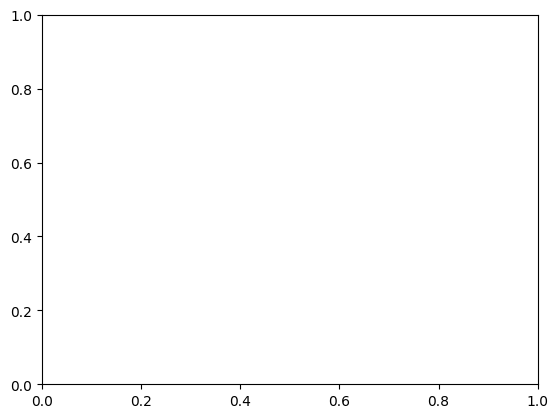

In [ ]:
def evaluate_graph(dictionary, corpus, texts, limit):
    c_scores = []
    models = []
    topic_range = list(range(5, limit + 1, 5))

    for k in topic_range:
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=SEED,
            passes=10,
            update_every=0,
        )
        coherence_model = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        c_scores.append(coherence_model.get_coherence())
        models.append(model)
        print(f"K={k} -> Coherencia: {c_scores[-1]:.4f}")

    return models, c_scores, topic_range


limit_k = 30
models, scores, topic_range = evaluate_graph(dictionary, corpus, documents, limit_k)

plt.plot(topic_range, scores)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.title("Búsqueda del K óptimo")
plt.show()

best_index = np.argmax(scores)
lda_model = models[best_index]
print(f"Mejor número de temas: {topic_range[best_index]}")


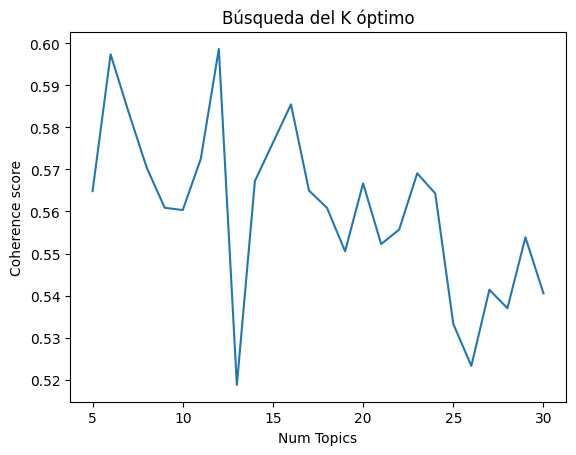

[np.float64(0.5648345898106998), np.float64(0.5973976686526735), np.float64(0.5836038331829955), np.float64(0.5704591203577141), np.float64(0.5608824804207371), np.float64(0.5603405695226853), np.float64(0.5725249553664158), np.float64(0.5986768797455828), np.float64(0.5187396013906063), np.float64(0.5672369506497927), np.float64(0.5763545279556583), np.float64(0.5854858066892501), np.float64(0.564963182502642), np.float64(0.5608515286154767), np.float64(0.5505231778492533), np.float64(0.5666831271712668), np.float64(0.5522477849652778), np.float64(0.5557118973909113), np.float64(0.5690788257728773), np.float64(0.564289710133466), np.float64(0.5332554653001585), np.float64(0.5232561334714947), np.float64(0.5413862801470561), np.float64(0.5369704368277772), np.float64(0.5538476001352562), np.float64(0.5405245885411997)]
Mejor número de temas: 12


In [ ]:
plt.plot(topic_range, scores)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.title("Búsqueda del K óptimo")
plt.show()

best_index = np.argmax(scores)
print(scores)
lda_model = models[best_index]
print(f"Mejor número de temas: {topic_range[best_index]}")


La K representa a la variable num_topics. Elegimos ``num_topics = 12`` ya que es el máximo de la búsqueda. El valor del coherence score está cerca del 0.6, por lo que los topics están decentemente definidos para nuestra columna.

Hemos guardado nuestro mejor modelo en la variable ``lda_model``.

In [20]:
unique_series = df['name'].unique()

def get_main_topics(text, model, dictionary):
    tokens = str(text).lower().split()
    bow = dictionary.doc2bow(tokens)
    topics_distribution = model.get_document_topics(bow)
    # Ordenamos por probabilidad de mayor a menor
    topics_distribution.sort(key=lambda x: x[1], reverse=True)
    return topics_distribution

data_list = []

for series_name in unique_series:
    topics = get_main_topics(series_name, lda_model, dictionary)
    if not topics:
        data_list.append({
            'name': series_name,
            'topic_id': None,
            'prob_topic': 0.0
        })
    else:
        for topic_id, prob in topics:
            data_list.append({
                'name': series_name,
                'topic_id': topic_id,
                'prob_topic': prob
            })

df_topics_mapped = pd.DataFrame(data_list)

print(df_topics_mapped.head(12))

               name  topic_id  prob_topic
0   Game of Thrones         2    0.394012
1   Game of Thrones         5    0.328082
2   Game of Thrones         1    0.027791
3   Game of Thrones         6    0.027791
4   Game of Thrones         0    0.027791
5   Game of Thrones         3    0.027791
6   Game of Thrones        11    0.027791
7   Game of Thrones         8    0.027791
8   Game of Thrones         9    0.027791
9   Game of Thrones         4    0.027791
10  Game of Thrones        10    0.027790
11  Game of Thrones         7    0.027790


In [9]:
total_series = len(unique_series)
print(total_series)

85513


Como el número de series es inmenso, vamos a hacer algunos análisis para poder responder a la pregunta.

Como se observa en el output en el que aparece la serie `Game of Thrones` (2 celdas arriba), el algoritmo LSA asigna probabilidades de pertenencia a cada topic por cada serie. Por motivos de simplificación del análisis, solo vamos a usar la máxima probabilidad de cada serie (Ej. 'Game of Thrones' --> prob_topic_2 = 0.385338).

Vamos a empezar con un clásico Top-N=10. En este caso se evaluará a las Top 10 mejores series, es decir, a las 10 series que tengan las mayores probabilidades de pertenencia a un topic, y también se evaluará a las Top 10 peores series, que son las que tienen las menores probabilidades de pertenencia a un topic.

In [21]:
# Nos aseguramos de tener solo la probabilidad máxima de cada serie
df_sorted = df_topics_mapped.sort_values(['name', 'prob_topic'], ascending=[True, False])

df_main_topics = df_sorted.drop_duplicates(subset=['name'])

# Obtener el TOP 10 de probabilidades más altas
top_10_high = df_main_topics.nlargest(10, 'prob_topic')[['name', 'topic_id', 'prob_topic']]

# Obtener el TOP 10 de probabilidades más bajas
top_10_low = df_main_topics[df_main_topics['prob_topic'] > 0].nsmallest(10, 'prob_topic')[['name', 'topic_id', 'prob_topic']]

print(" ---> TOP 10 SERIES CON MAYOR PROBABILIDAD DE TÓPICO")
print(top_10_high.to_string(index=False))

print("\n" + "-"*90 + "\n")

print(" ---> TOP 10 SERIES CON MENOR PROBABILIDAD DE TÓPICO")
print(top_10_low.to_string(index=False))

 ---> TOP 10 SERIES CON MAYOR PROBABILIDAD DE TÓPICO
                                                                                                                    name  topic_id  prob_topic
The Neat and Beautiful Girl at My New School Was My Childhood Friend Whom I Thought Was a Boy and I Played Together With         2    0.956257
                                                     Crazy Over His Fingers: Just the Two of Us in a Salon After Closing         2    0.934465
                                                   I Didn't Love You Because I Was a Family, But I Loved You as a Family         2    0.934423
                                                    The Woman in the House Across the Street from the Girl in the Window         3    0.929426
                                      Hensuki: Are You Willing to Fall in Love With a Pervert, As Long As She's a Cutie?         2    0.929404
                                                                        Love Flight: The 

Podemos observar que el Top-10 de peores series con menor probabilidad de pertenecer a un topic son nombres de series con carácteres de idiomas extrangeros o directamente nombres en otros idiomas, lo que tiene mucho sentido que nos de algo extremadamente bajo (de hecho, lo más bajo posible, 1/12).

Las series que tienen al menos un 90% de probabilidad de pertenecer a un topic, nos indicaría que el modelo LSA está muy seguro que pertenece a ese topic. Veamos cuales son:

In [22]:
# 1. Filtrar las series con probabilidad superior al 90%
df_high_confidence = df_topics_mapped[df_topics_mapped['prob_topic'] > 0.90].copy()

# 2. Calcular el número total de series únicas en este grupo
total_series_90 = df_high_confidence['name'].nunique()

# 3. Mostrar el conteo total
print(f"Número total de series con más del 90% de probabilidad: {total_series_90}")
print("-" * 65)

# 4. Mostrar el listado de nombres con su Topic ID y la probabilidad exacta
if total_series_90 > 0:
    # Ordenamos por probabilidad para ver las más exactas primero
    listado = df_high_confidence[['name', 'topic_id', 'prob_topic']].sort_values(by='prob_topic', ascending=False)

    print(f"{'Nombre de la Serie':<100} | {'Topic ID':<10} | {'Probabilidad':<12}")
    print("-" * 65)

    for _, row in listado.iterrows():
        print(f"{row['name'][:100]:<100} | {int(row['topic_id']):<10} | {row['prob_topic']:.4f}")
else:
    print("No se encontraron series que superen el umbral del 90%.")

Número total de series con más del 90% de probabilidad: 34
-----------------------------------------------------------------
Nombre de la Serie                                                                                   | Topic ID   | Probabilidad
-----------------------------------------------------------------
The Neat and Beautiful Girl at My New School Was My Childhood Friend Whom I Thought Was a Boy and I  | 2          | 0.9563
Crazy Over His Fingers: Just the Two of Us in a Salon After Closing                                  | 2          | 0.9345
I Didn't Love You Because I Was a Family, But I Loved You as a Family                                | 2          | 0.9344
The Woman in the House Across the Street from the Girl in the Window                                 | 3          | 0.9294
Hensuki: Are You Willing to Fall in Love With a Pervert, As Long As She's a Cutie?                   | 2          | 0.9294
Love Flight: The Last Love at the End of the Sky                 

Haciendo una rápida búsqueda en Internet, vemos que la mayoría de las series del topic 5 son animes/mangas japoneses un tanto extraños.

Por último veamos las confianzas de probabilidad de que una serie pertenezca a un topic en función de cada rango de confianza. Observemos estos rangos:
- 50%-59.9%
- 60%-69.9%
- 70%-79.9%
- 80%-89.9%
- 90%-100%

Con esto podemos tener una distribución de probabilidad de las confianzas de las mejores probabilidades de pertenencia a cada topic de cada una de las series.

In [23]:
# 1. Obtener la probabilidad máxima de cada serie única
df_max_probs = df_topics_mapped.groupby('name')['prob_topic'].max().reset_index()
total_series = len(df_max_probs)

# 2. Definir los rangos y etiquetas
bins = [0.5, 0.6, 0.7, 0.8, 0.9, 1.01] # El 1.01 es para incluir el 1.0 exacto
labels = ['50% - 59.9%', '60% - 69.9%', '70% - 79.9%', '80% - 89.9%', '90% - 100%']

# 3. Categorizar cada serie en su rango
df_max_probs['range'] = pd.cut(df_max_probs['prob_topic'], bins=bins, labels=labels, right=False)

# 4. Calcular conteos y porcentajes
counts = df_max_probs['range'].value_counts().reindex(labels[::-1]) # Invertimos para ver 90-100 primero
percentages = (counts / total_series) * 100

# 5. Printear el reporte
print(f"ANÁLISIS DE CALIDAD POR SEGMENTOS (Total series: {total_series})")
print("-" * 55)
print(f"{'Rango de Probabilidad':<25} | {'Nº Series':<10} | {'Porcentaje':<10}")
print("-" * 55)

for label in labels[::-1]:
    count = counts[label]
    perc = percentages[label]
    print(f"{label:<25} | {int(count):<10} | {perc:>8.2f}%")

# 6. Calcular el "Ratio de Descarte" (series por debajo del 50%)
series_low = total_series - counts.sum()
perc_low = (series_low / total_series) * 100
print("-" * 55)
print(f"{'Bajo (menor al 50%)':<25} | {int(series_low):<10} | {perc_low:>8.2f}%")

ANÁLISIS DE CALIDAD POR SEGMENTOS (Total series: 85513)
-------------------------------------------------------
Rango de Probabilidad     | Nº Series  | Porcentaje
-------------------------------------------------------
90% - 100%                | 34         |     0.04%
80% - 89.9%               | 6372       |     7.45%
70% - 79.9%               | 10659      |    12.46%
60% - 69.9%               | 19554      |    22.87%
50% - 59.9%               | 23040      |    26.94%
-------------------------------------------------------
Bajo (menor al 50%)       | 25854      |    30.23%


Podemos observar en esta distribución de probabilidad de bins que en el 50% superior el porcentaje suma un total de *69.03%*, lo que indica que la gran mayoría de los nombres de series superan el umbral del 50% de confianza de pertenencia a un topic concreto.

Ahora veamos el gráfico de distribuciones de probabilidad correspondiente a la tabla completa en base a la frecuencia de probabilidad del topic dominante.

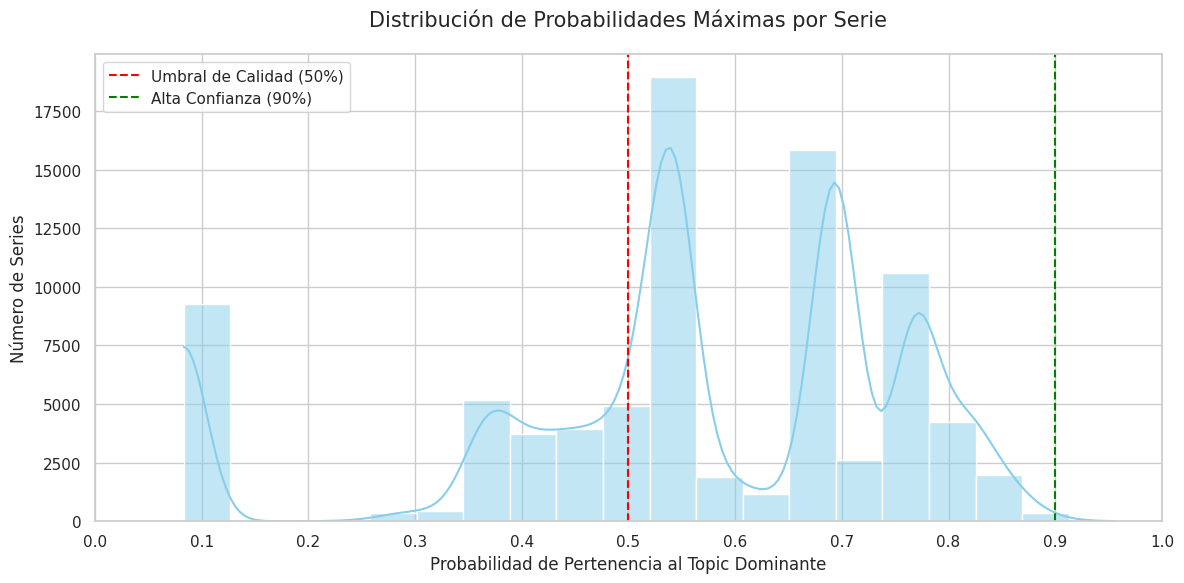

In [13]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Crear el histograma con la curva de densidad (KDE)
# Usamos df_max_probs['prob_topic'] que contiene los valores continuos
sns.histplot(df_max_probs['prob_topic'], bins=20, kde=True, color="skyblue", edgecolors='white')

# 2. Añadir líneas verticales para marcar tus rangos críticos
plt.axvline(x=0.5, color='red', linestyle='--', label='Umbral de Calidad (50%)')
plt.axvline(x=0.9, color='green', linestyle='--', label='Alta Confianza (90%)')

# 3. Personalización de ejes y etiquetas
plt.title('Distribución de Probabilidades Máximas por Serie', fontsize=15, pad=20)
plt.xlabel('Probabilidad de Pertenencia al Topic Dominante', fontsize=12)
plt.ylabel('Número de Series', fontsize=12)

# Ajustar los ticks del eje X para que coincidan con tus bins
plt.xticks([0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

plt.legend()
plt.tight_layout()
plt.show()

Hay muchas combinaciones de géneros, así que usaremos todos los géneros con los que se hacen las combinaciones para hacer la comparación de los topics y se grafican los topics de máxima probabilidad de pertenencia.

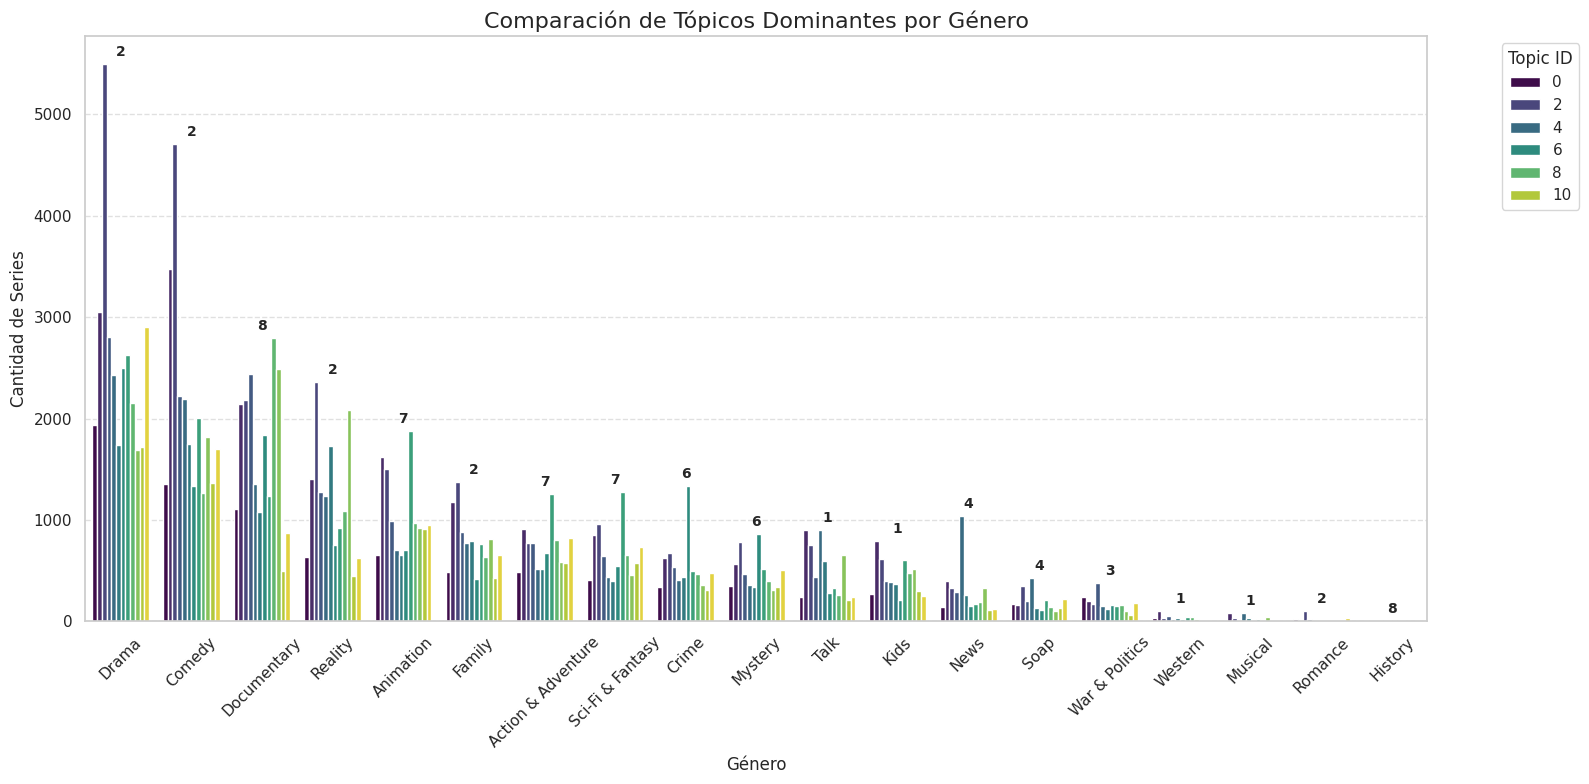

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Tópico principal por serie + géneros
df_main = df_topics_mapped.sort_values('prob_topic', ascending=False).drop_duplicates('name')
df_plot = pd.merge(df_main, df[['name', 'genres']], on='name')

# 2. Explode de géneros
df_plot['genres'] = df_plot['genres'].str.split(', ')
df_plot = df_plot.explode('genres').reset_index(drop=True)

# 3. Forzar los 12 topics en la leyenda
all_topics = list(range(12))

# 4. Ordenar géneros si quieres mantener una gráfica legible
genre_order = df_plot['genres'].value_counts().index.tolist()

# 5. Crear tabla de conteos por género y topic
counts = (
    df_plot.groupby(['genres', 'topic_id'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(16, 8))

ax = sns.countplot(
    data=df_plot,
    x='genres',
    hue='topic_id',
    hue_order=all_topics,
    order=genre_order,
    palette='viridis'
)

# 6. Encontrar el topic dominante por género
max_topics = (
    counts.sort_values(['genres', 'count'], ascending=[True, False])
    .drop_duplicates('genres')
)

# 7. Anotar el ID del topic dominante en cada género
for i, genre in enumerate(genre_order):
    row = max_topics[max_topics['genres'] == genre]
    if not row.empty:
        top_topic = int(row['topic_id'].iloc[0])
        top_count = row['count'].iloc[0]
        ax.text(
            i,
            top_count + 50,
            str(top_topic),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

# 8. Estética
plt.title('Comparación de Tópicos Dominantes por Género', fontsize=16)
plt.xlabel('Género', fontsize=12)
plt.ylabel('Cantidad de Series', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Topic ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Este gráfico nos da bastante información. Para empezar, vemos que básicamente predomina el ``topic 5``. Este topic es especialmente importante en los generos ``Drama, Comedy, Animation, Action & Adventure, Sci-Fi & Fantasy, Mistery y Kids``. Esto podría cuadrar bastante con lo visto anteriormente de que las series con alta probabilidad de pertenencia al topic 5 eran animes.

Por otro lado, vemos que el topic 5 solo destaca en el género de Documentary, aunque también tiene una "fuerte" presencia en el de War & Politics, lo cual tendría sentido.

También se ve que el ``topic 4`` es dominante en ``Talk y News``. Algo también que tiene sentido. 

En general, parece que, aunque solo hemos hablado de 4 topics, el trabajo que ha hecho LDA tiene sentido. Otra comprobación que podríamos hacer es la siguiente:

- Buscar todo las combinaciones de géneros que existen en el dataset.
- Buscar su topic principal
- Ver si el topic o topics principales tienen que ver con el topic/topics principales de las partes por separado.

De esta forma, veremos si se mantiene la coherencia. Es decir, si el topic principal de los generos Drama y Comedia es el 5, tendría sentido que una serie con ambos generos fuese del topic 5. Veamoslo:


In [15]:
import pandas as pd

# 1. Tópico principal por serie
df_main_topic = df_topics_mapped.sort_values('prob_topic', ascending=False).drop_duplicates('name')

# 2. Unimos con géneros originales
df_full = pd.merge(df_main_topic, df[['name', 'genres']], on='name')

# Nos quedamos solo con filas válidas
df_full = df_full[df_full['genres'].notna() & (df_full['genres'] != '')].copy()

# 3. Explode para trabajar con géneros individuales
df_exploded = df_full.copy()
df_exploded['genres'] = df_exploded['genres'].str.split(', ')
df_exploded = df_exploded.explode('genres').reset_index(drop=True)

# 4. Función para sacar top-n topics más frecuentes
def top_n_topics(series, n=1):
    counts = series.value_counts()
    return counts.head(n).index.tolist()

# 5. Top 1, top 2 y top 3 topics por género individual
genre_top1 = (
    df_exploded.groupby('genres')['topic_id']
    .apply(lambda x: top_n_topics(x, 1))
    .to_dict()
)

genre_top2 = (
    df_exploded.groupby('genres')['topic_id']
    .apply(lambda x: top_n_topics(x, 2))
    .to_dict()
)

genre_top3 = (
    df_exploded.groupby('genres')['topic_id']
    .apply(lambda x: top_n_topics(x, 3))
    .to_dict()
)

# 6. Topic dominante por combinación exacta de géneros
combo_top_topics = (
    df_full.groupby('genres')['topic_id']
    .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
    .reset_index()
)

# 7. Comprobación de coherencia
results = []

for _, row in combo_top_topics.iterrows():
    combo = row['genres']
    combo_topic = row['topic_id']

    individual_genres = combo.split(', ')

    # Top 1 de cada género individual
    individual_top1 = []
    for g in individual_genres:
        individual_top1.extend(genre_top1.get(g, []))
    individual_top1 = sorted(set(individual_top1))

    # Top 2 de cada género individual
    individual_top2 = []
    for g in individual_genres:
        individual_top2.extend(genre_top2.get(g, []))
    individual_top2 = sorted(set(individual_top2))

    # Top 3 de cada género individual
    individual_top3 = []
    for g in individual_genres:
        individual_top3.extend(genre_top3.get(g, []))
    individual_top3 = sorted(set(individual_top3))

    coherent_top1 = combo_topic in individual_top1
    coherent_top2 = combo_topic in individual_top2
    coherent_top3 = combo_topic in individual_top3

    results.append({
        'genres_combination': combo,
        'combo_topic': combo_topic,
        'individual_genres': individual_genres,
        'individual_top1_topics': individual_top1,
        'individual_top2_topics': individual_top2,
        'individual_top3_topics': individual_top3,
        'coherent_top1': coherent_top1,
        'coherent_top2': coherent_top2,
        'coherent_top3': coherent_top3
    })

results_df = pd.DataFrame(results)

# 8. Resumen global
total_combos = len(results_df)

num_coherent_top1 = results_df['coherent_top1'].sum()
num_coherent_top2 = results_df['coherent_top2'].sum()
num_coherent_top3 = results_df['coherent_top3'].sum()

pct_top1 = 100 * num_coherent_top1 / total_combos if total_combos > 0 else 0
pct_top2 = 100 * num_coherent_top2 / total_combos if total_combos > 0 else 0
pct_top3 = 100 * num_coherent_top3 / total_combos if total_combos > 0 else 0

print("### COMPROBACIÓN DE COHERENCIA ENTRE COMBINACIONES Y GÉNEROS INDIVIDUALES ###")
print("-" * 80)
print(f"Total de combinaciones analizadas: {total_combos}")
print()
print(f"Coherencia con TOP 1 dominante: {num_coherent_top1} / {total_combos} ({pct_top1:.2f}%)")
print(f"Coherencia con TOP 2 dominantes: {num_coherent_top2} / {total_combos} ({pct_top2:.2f}%)")
print(f"Coherencia con TOP 3 dominantes: {num_coherent_top3} / {total_combos} ({pct_top3:.2f}%)")

print("\nCombinaciones que NO cumplen ni siquiera con el TOP 3:")
display(results_df[~results_df['coherent_top3']])

### COMPROBACIÓN DE COHERENCIA ENTRE COMBINACIONES Y GÉNEROS INDIVIDUALES ###
--------------------------------------------------------------------------------
Total de combinaciones analizadas: 1406

Coherencia con TOP 1 dominante: 586 / 1406 (41.68%)
Coherencia con TOP 2 dominantes: 786 / 1406 (55.90%)
Coherencia con TOP 3 dominantes: 972 / 1406 (69.13%)

Combinaciones que NO cumplen ni siquiera con el TOP 3:


,genres_combination,combo_topic,individual_genres,individual_top1_topics,individual_top2_topics,individual_top3_topics,coherent_top1,coherent_top2,coherent_top3
4,"Action & Adventure, Animation, Comedy, Crime, ...",7,"[Action & Adventure, Animation, Comedy, Crime,...","[5, 10]","[4, 5, 9, 10, 11]","[1, 4, 5, 8, 9, 10, 11]",False,False,False
8,"Action & Adventure, Animation, Comedy, Crime, ...",2,"[Action & Adventure, Animation, Comedy, Crime,...","[5, 10]","[4, 5, 9, 10, 11]","[1, 4, 5, 8, 9, 10, 11]",False,False,False
14,"Action & Adventure, Animation, Comedy, Crime, ...",6,"[Action & Adventure, Animation, Comedy, Crime,...","[5, 10, 11]","[4, 5, 9, 10, 11]","[1, 4, 5, 8, 9, 10, 11]",False,False,False
16,"Action & Adventure, Animation, Comedy, Crime, ...",7,"[Action & Adventure, Animation, Comedy, Crime,...","[5, 10]","[4, 5, 9, 10, 11]","[1, 4, 5, 8, 9, 10, 11]",False,False,False
19,"Action & Adventure, Animation, Comedy, Documen...",7,"[Action & Adventure, Animation, Comedy, Docume...","[5, 11]","[4, 5, 9, 11]","[1, 4, 5, 8, 9, 11]",False,False,False
...,...,...,...,...,...,...,...,...,...
1395,"Sci-Fi & Fantasy, Soap",0,"[Sci-Fi & Fantasy, Soap]","[5, 6]","[5, 6, 11]","[1, 5, 6, 9, 11]",False,False,False
1396,"Sci-Fi & Fantasy, Talk",3,"[Sci-Fi & Fantasy, Talk]","[4, 5]","[4, 5, 11]","[4, 5, 7, 9, 11]",False,False,False
1397,"Sci-Fi & Fantasy, Western",0,"[Sci-Fi & Fantasy, Western]","[5, 11]","[4, 5, 11]","[4, 5, 9, 11]",False,False,False
1400,"Soap, War & Politics",4,"[Soap, War & Politics]","[0, 6]","[0, 5, 6, 11]","[0, 1, 5, 6, 11]",False,False,False


Como vemos, si comparamos solo el topic principal con uno de los topics principales de sus partes separadas, el 40.26% cumplen la regla.

En cambio si comparamos también con su segundo topic, aumenta a 59.6%. Y si también miramos hasta el 3 topics (lo cual tampoco sería muy descabellado, ya que tenemos 12), asciende a 67.07%.

Esto número concuerdan bastante con el Coherence Score ($C_v$) que hemos conseguido. No podemos pretender un 100% de acierto si el coherence es de 0.6.

Ahora, haremos un breve estudio sobre las series atípicas del dataset.

Consideramos una serie como "atípica" cuando su probabilidad máxima de pertenencia a un tópico es inusualmente baja. Esto significa que el modelo está "confundido", ya que la serie no pertenece a ningún tema y sus palabras están dispersas entre muchos tópics, o bien usa palabras que el modelo apenas reconoce.

Optamos por el siguiente procedimiento para detectar anomalías:
Usaremos `Isolation Forest`, un algoritmo de Machine Learning diseñado específicamente para la detección de anomalías. En este algoritmo, en lugar de prestar atención a solo una columna, se aíslan las observaciones. Las series que se aíslen más rápido en las particiones del árbol son las que el modelo considera más incoherentes respecto al resto del dataset.

In [16]:
from sklearn.ensemble import IsolationForest

# 1. Preparar features
df_outliers = df_topics_mapped.groupby('name')['prob_topic'].agg(['max', 'mean', 'std', 'count']).fillna(0)

# 2. Modelo
model_if = IsolationForest(contamination=0.05, random_state=42)
df_outliers['anomaly_score'] = model_if.fit_predict(df_outliers[['max', 'mean', 'std']])

# 3. Filtrar anomalías
atípicas_avanzadas = df_outliers[df_outliers['anomaly_score'] == -1].sort_values(by='max')

# --- NUEVO: añadir texto ---
df_text = df[['name', 'texto_lematizado_pos']].drop_duplicates('name')
atípicas_avanzadas = atípicas_avanzadas.reset_index().merge(df_text, on='name', how='left')

# 4. Mostrar resultados
print(f"### DETECCIÓN AVANZADA CON ISOLATION FOREST ###")
print(f"Series detectadas como anomalías: {len(atípicas_avanzadas)}")
print("-" * 100)
print(f"{'Nombre de la Serie':<45} | {'Confianza Max':<10} | {'Texto (preview)':<40}")
print("-" * 100)

for _, row in atípicas_avanzadas.head(20).iterrows():
    texto_preview = str(row['texto_lematizado_pos'])[:40]
    print(f"{str(row['name'])[:45]:<45} | {row['max']:.4f} | {texto_preview}")

### DETECCIÓN AVANZADA CON ISOLATION FOREST ###
Series detectadas como anomalías: 4224
----------------------------------------------------------------------------------------------------
Nombre de la Serie                            | Confianza Max | Texto (preview)                         
----------------------------------------------------------------------------------------------------
Ποιος θέλει να γίνει εκατομμυριούχος          | 0.0833 | british want millionaire greek format ca
Bǎi Wàn Zhì Duō Xīng                          | 0.0833 | bǎi wàn zhì duō xīng chinese game lǐ fán
Наживка для ангела                            | 0.0833 | summary наживка для ангела yet hang ther
𝐁𝐮𝐢𝐥𝐝𝐢𝐧𝐠 𝐍𝐨 - 𝐗𝐕𝐈𝐈                            | 0.0833 | two stranger always watch one smile one 
Dzień Dobry Wakacje                           | 0.0833 | dzień dobry wakacje polish morning spino
Dinhing Dapita Sadya                          | 0.0833 | dinhing dapita sadya weekly entertainmen
Dhoom Machaao Dhoo

4260 series catalogadas como anomalía representa a un 4.97% de las series (4260/85643). Si nos fijamos en los nombres de las series, son series con nombres en idiomas extranos y nada conocidas en occidente. Además, si bien el overview está en inglés, contiene muchas palabras (imaginamos que nombres propios) extranjeras.

Lo curioso es que el detector ha repartido la incertidumbre equitativamente entre los 15 topics (1/12 ≈ 0.0833), lo que significa que para esas series, el modelo tiene una incertidumbre total: ha repartido la probabilidad equitativamente entre todos los topics porque no reconoce absolutamente ninguna palabra del título.

El modelo ha entrado en un estado de confusión máxima, así que le da la misma probabilidad de pertenencia a cada Topic.

El sentido de estas anomalías puede venir de que nuestro modelo de LSA al haber sido entrenado con el texto de las overviews, no se haya encontrado nunca con esas palabras, lo que hace que la asignación a un topic sea casi imposible hacer y se le cataloga como anomalía.

# NER

Para esta fase de Reconocimiento de Entidades Nombradas (NER) he elegido **Flair**. A diferencia de otras librerías que usan modelos estadísticos más tradicionales, Flair es un framework de vanguardia (*State-of-the-Art*) que destaca por:

1. **Arquitectura BiLSTM-CRF:** Utiliza redes neuronales profundas bidireccionales combinadas con *Conditional Random Fields*, una de las mejores arquitecturas para etiquetado secuencial.
2. **Embeddings Contextuales (Flair Embeddings):** Entiende el significado de las palabras a nivel de caracteres y según su contexto. Esto es vital en sinopsis de series, donde una palabra puede ser un nombre propio o un verbo dependiendo de la frase (ej. "Will" como personaje de *Stranger Things* vs "will" como verbo futuro).
3. **Precisión:** Logra una precisión altísima en el reconocimiento de Personas (PER), Localizaciones (LOC), Organizaciones (ORG) y Miscelánea (MISC).

In [17]:
!pip install flair


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 62.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.1/203.1 kB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 142.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [18]:
import pandas as pd
import torch
from flair.data import Sentence
from flair.models import SequenceTagger
from tqdm import tqdm
from collections import Counter

torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Cargando modelo NER de Flair...")
tagger = SequenceTagger.load('ner')
print("¡Modelo cargado y listo!")


Cargando modelo NER de Flair...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


pytorch_model.bin:   0%|          | 0.00/419M [00:00<?, ?B/s]

2026-04-16 10:01:40,519 SequenceTagger predicts: Dictionary with 20 tags: <unk>, O, S-ORG, S-MISC, B-PER, E-PER, S-LOC, B-ORG, E-ORG, I-PER, S-PER, B-MISC, I-MISC, E-MISC, I-ORG, B-LOC, E-LOC, I-LOC, <START>, <STOP>
¡Modelo cargado y listo!


In [19]:
df_ner = df.copy()

def extract_entities(text):
    if not isinstance(text, str) or text.strip() == '':
        return []

    sentence = Sentence(text)
    tagger.predict(sentence)
    entities = [(entity.text, entity.get_label('ner').value) for entity in sentence.get_spans('ner')]
    return entities

tqdm.pandas(desc="Extrayendo Entidades (NER)")
df_ner['entities'] = df_ner['overview'].progress_apply(extract_entities) #Lo hacemos con el texto sin preprocesar, porque si quitamos contexto, NER fallará.

display(df_ner[['overview', 'entities']].head())

Extrayendo Entidades (NER):   0%|          | 0/91967 [00:00<?, ?it/s]

Extrayendo Entidades (NER): 100%|██████████| 91967/91967 [1:26:22<00:00, 17.75it/s]


,overview,entities
0,Seven noble families fight for control of the ...,"[(Westeros, LOC), (Night's Watch, MISC)]"
1,"To carry out the biggest heist in history, a m...","[(National Coinage, ORG), (Spain, LOC)]"
2,"When a young boy vanishes, a small town uncove...",[]
3,Sheriff's deputy Rick Grimes awakens from a co...,"[(Rick Grimes, PER)]"
4,"Bored and unhappy as the Lord of Hell, Lucifer...","[(Lord of Hell, PER), (Lucifer Morningstar, PE..."


Una vez aplicado el NER, vamos a ver los resultados que hemos conseguido. Importante recalcar que lo hemos hecho sobre el texto sin preprocesar, porque NER necesita el contexto. Si lo hiciesemos con el texto preprocesado, probablemente no funcionaría muy bien.

In [20]:
df_ner.to_csv("/content/drive/MyDrive/BIG DATA/data_NER.csv", index=False)

Vamos a empezar por ver las tres entidades más mencionadas en todo el corpus:

In [21]:
from collections import Counter

all_entities = [ent for sublist in df_ner['entities'] for ent in sublist]

nombres_entidades = [ent[0] for ent in all_entities]
top_3_absoluto = Counter(nombres_entidades).most_common(3)

print("TOP 3 ABSOLUTO DE ENTIDADES MÁS MENCIONADAS (GLOBAL):")
for i, (nombre, conteo) in enumerate(top_3_absoluto, 1):
    print(f" {i}. {nombre} ({conteo} apariciones)")

print("-" * 50)

TOP 3 ABSOLUTO DE ENTIDADES MÁS MENCIONADAS (GLOBAL):
 1. American (5460 apariciones)
 2. British (3462 apariciones)
 3. Canadian (1898 apariciones)
--------------------------------------------------


Como vemos, son ``American, British y Canadian``. Esto es mala señal, porque son palabras o entidades que aportan poca o ninguna información relevante a la hora de recomendar serie.

Ahora, veamos el Top 5 de entidades mencionadas, pero esta vez por categoria:


In [22]:
categorias = ['PER', 'LOC', 'ORG', 'MISC']
nombres_categorias = {
    'PER': 'Personajes (PER)',
    'LOC': 'Lugares (LOC)',
    'ORG': 'Organizaciones (ORG)',
    'MISC': 'Miscelánea (MISC)'
}

for cat in categorias:
    entidades_cat = [ent[0] for ent in all_entities if ent[1] == cat]
    top_5_cat = Counter(entidades_cat).most_common(5)

    if top_5_cat:
        print(f"\n📌 TOP 5 - {nombres_categorias[cat]}:")
        for i, (nombre, conteo) in enumerate(top_5_cat, 1):
            print(f" {i}. {nombre} ({conteo} apariciones)")


📌 TOP 5 - Personajes (PER):
 1. God (241 apariciones)
 2. David (162 apariciones)
 3. Alex (154 apariciones)
 4. Sam (145 apariciones)
 5. Jack (145 apariciones)

📌 TOP 5 - Lugares (LOC):
 1. United States (1617 apariciones)
 2. UK (1276 apariciones)
 3. Japan (1261 apariciones)
 4. Australia (1181 apariciones)
 5. America (1157 apariciones)

📌 TOP 5 - Organizaciones (ORG):
 1. NBC (1444 apariciones)
 2. BBC (1395 apariciones)
 3. ABC (1291 apariciones)
 4. ITV (1207 apariciones)
 5. CBS (1192 apariciones)

📌 TOP 5 - Miscelánea (MISC):
 1. American (5460 apariciones)
 2. British (3462 apariciones)
 3. Canadian (1898 apariciones)
 4. Australian (1758 apariciones)
 5. Japanese (1370 apariciones)


- El Top 5 de personajes no es especialmente útil. Tal vez God podría darnos alguna información útil para las recomendaciones, pero el resto son nombre comunes.
- Con los lugares pasa algo parecido que con el top 3 global. 
- Las organizaciones podrían servir para recomendar algo si quieres el género News o Talk
- Y la miscelanea más de lo mismo, poca información aporta.



# Entidades más frecuentes por género

Vamos a hacer un pequeño análisis para ver cuales son las entidades más frecuentes por género. 

In [23]:
from collections import Counter

# Copia
df_ent = df_ner.copy()

# Explode géneros
df_ent['genres'] = df_ent['genres'].str.split(', ')
df_ent = df_ent.explode('genres')

# Explode entidades
df_ent = df_ent.explode('entities')

# Separar texto y tipo de entidad
df_ent[['entity_text', 'entity_type']] = pd.DataFrame(
    df_ent['entities'].tolist(),
    index=df_ent.index
)

In [27]:
entity_counts_by_genre = (
    df_ent.groupby(['genres', 'entity_text'])
    .size()
    .reset_index(name='count')
)

In [40]:
top_entities_by_genre = (
    entity_counts_by_genre
    .sort_values(['genres', 'count'], ascending=[True, False])
    .groupby('genres')
    .head(40)
)

In [41]:
for genre in top_entities_by_genre['genres'].unique():
    print(f"\n### {genre} ###")
    display(
        top_entities_by_genre[top_entities_by_genre['genres'] == genre][['entity_text', 'count']]
        .reset_index(drop=True)
    )


### Action & Adventure ###


,entity_text,count
0,American,410
1,Earth,403
2,Japan,342
3,Japanese,291
4,United States,188
5,Hong Kong,175
6,Chinese,160
7,British,151
8,China,124
9,ABC,96



### Animation ###


,entity_text,count
0,Japan,596
1,Japanese,531
2,Earth,508
3,American,412
4,United States,237
5,Tokyo,235
6,English,213
7,Canadian,200
8,Canada,183
9,French,180



### Comedy ###


...

,entity_text,count
0,American,476
1,British,303
2,Canadian,230
3,Australian,204
4,ITV,133
5,BBC,122
6,NBC,115
7,UK,103
8,ABC,101
9,CBC Television,91



### War & Politics ###


,entity_text,count
0,World War II,144
1,German,117
2,Japanese,114
3,American,112
4,British,109
5,Japan,73
6,United States,73
7,Hitler,71
8,Chinese,70
9,China,67



### Western ###


,entity_text,count
0,American,120
1,ABC,99
2,NBC,68
3,American Western,61
4,Western,55
5,CBS,54
6,United States,35
7,California,22
8,Texas,18
9,Canadian,17


Como vemos, la mayoría de las entidades en el TOP se repiten en todos los géneros. Esto significa que basándonos en el TOP, no podríamos diferenciar una género de otro. En cambio, si nos fijamos en posiciones más bajas, si que parece empezar a aparecer información útil:

- Por ejemplo en el caso de Western, vemos que aparecen Native American, Civil War, Wild West... Palabras que tienen que ver más con el género como tal.

- En el caso de War & Politics, aparecen términos muy interesantes, como World War II, Hitler, Japan...

No obstante, no consideramos especialmente útil toda esta información, porque en realidad el género ya nos está dando muchisima información. Aun así, tener el corpus etiquetado nunca es algo que venga mal.

## Relación entre entidades y topics

Ahora veamos la relación entre entidades y topics. Este análisis será mas complicado, pues no sabes a ciencia cierta qué es cada topic. Sí que podemos hacenos un poco a la idea sobre qué pueden ir ciertos topics (como el 5 con el Anime), pero no sabemos exactamente qué representan.

In [31]:
df_main_topic = df_topics_mapped.sort_values('prob_topic', ascending=False).drop_duplicates('name')

df_ent_topics = pd.merge(df_ent, df_main_topic[['name', 'topic_id']], on='name')

In [32]:
entity_counts_by_topic = (
    df_ent_topics.groupby(['topic_id', 'entity_text'])
    .size()
    .reset_index(name='count')
)

In [42]:
top_entities_by_topic = (
    entity_counts_by_topic
    .sort_values(['topic_id', 'count'], ascending=[True, False])
    .groupby('topic_id')
    .head(40)
)


In [43]:
for topic in top_entities_by_topic['topic_id'].unique():
    print(f"\n### Topic {int(topic)} ###")
    display(
        top_entities_by_topic[top_entities_by_topic['topic_id'] == topic][['entity_text', 'count']]
        .reset_index(drop=True)
    )


### Topic 0 ###


,entity_text,count
0,American,452
1,British,331
2,German,320
3,Japan,316
4,Earth,176
5,Japanese,174
6,United States,170
7,NBC,135
8,Chinese,130
9,America,123



### Topic 1 ###


,entity_text,count
0,American,615
1,British,331
2,Italian,189
3,Canadian,184
4,ABC,162
5,Australian,142
6,NBC,141
7,BBC,140
8,UK,140
9,Japanese,137



### Topic 2 ###


...

,entity_text,count
0,American,686
1,Earth,408
2,British,340
3,United States,309
4,Canadian,291
5,Japan,262
6,Australian,257
7,Japanese,257
8,Australia,225
9,Canada,215



### Topic 10 ###


,entity_text,count
0,American,583
1,British,266
2,United States,183
3,Canadian,179
4,America,165
5,Australian,164
6,Earth,149
7,Japan,125
8,Japanese,125
9,UK,123



### Topic 11 ###


,entity_text,count
0,American,874
1,British,596
2,Australian,403
3,America,328
4,Canadian,327
5,United States,301
6,Australia,280
7,UK,280
8,BBC,254
9,Earth,245


A simple vista, somos totalmente incapaces de saber el tema que trata cada Topic. Todos tienen el top 40 extremadamente parecido, lo que dificulta su diferenciación.

A continuación, vamos a probar a hacer NER pero con el texto preprocesado, para ver si sacamos algo útil.

In [45]:
df_ner_prep = df.copy()

def extract_entities(text):
    if not isinstance(text, str) or text.strip() == '':
        return []

    sentence = Sentence(text)
    tagger.predict(sentence)
    entities = [(entity.text, entity.get_label('ner').value) for entity in sentence.get_spans('ner')]
    return entities

tqdm.pandas(desc="Extrayendo Entidades (NER)")
df_ner_prep['entities'] = df_ner_prep['texto_lematizado_pos'].progress_apply(extract_entities)

display(df_ner_prep[['texto_lematizado_pos', 'entities']].head())

Extrayendo Entidades (NER):   0%|          | 0/91967 [00:00<?, ?it/s]

Extrayendo Entidades (NER): 100%|██████████| 91967/91967 [49:29<00:00, 30.97it/s]  


,texto_lematizado_pos,entities
0,seven noble family fight control mythical land...,[]
1,carry big heist history mysterious man call pr...,[]
2,boy vanishes small town uncovers mystery invol...,[]
3,sheriff deputy rick grime awaken coma postapoc...,[]
4,bore unhappy lord hell lucifer morningstar aba...,"[(los angeles, LOC), (chloe decker, PER)]"


In [46]:
df_ner_prep.to_csv("/content/drive/MyDrive/BIG DATA/data_NER.csv", index=False)

- Responder a las siguientes preguntas:
   - Entidades más frecuentes por *genre*.
   - Relación entre entidades y topics.

In [47]:
display(df_ner_prep[['texto_lematizado_pos', 'entities']].head(40))

,texto_lematizado_pos,entities
0,seven noble family fight control mythical land...,[]
1,carry big heist history mysterious man call pr...,[]
2,boy vanishes small town uncovers mystery invol...,[]
3,sheriff deputy rick grime awaken coma postapoc...,[]
4,bore unhappy lord hell lucifer morningstar aba...,"[(los angeles, LOC), (chloe decker, PER)]"
5,present offer bold subversive archie betty ver...,[]
6,hundred cashstrapped player accept strange inv...,[]
7,walter white new mexico chemistry teacher diag...,[]
8,shaun murphy surgeon autism savant syndrome re...,"[(shaun murphy, PER)]"
9,wanda maximoff visiontwo superpowered being id...,[]
